# Evaluation. VLLM. Test time scaling. PEFT.

---

## LLM Eval

### Обзор бенчмарков для LLM

| Бенчмарк       | Область оценки              | Описание                                                                 | Примеры задач                             |
|----------------|-----------------------------|--------------------------------------------------------------------------|-------------------------------------------|
| **MMLU**       | Знания, мультидисциплинарность | Massive Multitask Language Understanding, проверяет знания по 57 предметам | История, медицина, математика и др.       |
| **HELLASWAG**  | Здравый смысл               | Проверка способности дополнять предложения логически                      | Завершение предложений                     |
| **ARC**        | Научные знания (K-12)       | AI2 Reasoning Challenge, тест школьного уровня                           | Научные вопросы с множественным выбором   |
| **GSM8K**      | Арифметика и рассуждение    | Grade School Math 8K — математические задачи для начальной школы        | Задачи на многошаговое рассуждение        |
| **TruthfulQA** | Правдоподобие vs. достоверность | Проверка способности избегать «убедительной, но ложной» информации       | Вопросы на правдивость                    |
| **WinoGrande** | Разрешение кореференций     | Проверка способности понимать, к кому относится местоимение              | Задачи в стиле Winograd Schema            |
| **OpenBookQA** | Комбинированные знания      | Требует знаний из «открытой книги» и способности их применять            | Применение фактов для вывода              |
| **HumanEval**  | Генерация кода              | Проверка способности LLM генерировать код, который проходит тесты        | Программные задачи с проверкой решений    |
| **MT-Bench**   | Диалоговые способности      | Multi-turn chat benchmark, фокус на диалогах и инструментах              | Рейтинги на основе GPT-4 / человеческих   |


### Сравнение плюсов и минусов оценочных подходов LLM

| Подход             | Плюсы                                                                 | Минусы                                                                 |
|--------------------|------------------------------------------------------------------------|------------------------------------------------------------------------|
| **Likelihood-based** | - Объективная и воспроизводимая метрика<br>- Эффективен по ресурсам<br>- Подходит для обучения и fine-tuning<br>- Хорош в zero-shot режиме | - Не отражает поведение генерации<br>- Чувствителен к формулировкам<br>- Может переоценивать запомненные ответы |
| **Decoding-based**   | - Ближе к реальному использованию<br>- Гибкая оценка: стиль, логика, креативность<br>- Учитывает reasoning и формат вывода | - Зависит от метода декодирования<br>- Требует human evaluation или сложных метрик<br>- Вычислительно дорогой<br>- Ошибки парсинга |


### Не всё так просто

- Бенчмарки утекают.
- Использовать людей для оценки LLM может быть дорого и долго (а иногда не надёжно) — LLM Arena.
- Можно использовать отдельную LLM для оценки новой модели. Но такая оценка может быть смещена.


### MMLU Example

```md
📘 Category: High School Biology

> Which of the following processes is part of cellular respiration?

A) Photosynthesis
B) Glycolysis
C) Transcription
D) DNA replication

✅ Correct Answer: B) Glycolysis
```

### [lm-evaluation-harness](https://github.com/EleutherAI/lm-evaluation-harness)

In [ ]:
!git clone --depth 1 https://github.com/EleutherAI/lm-evaluation-harness
!cd lm-evaluation-harness && pip install -e .

In [ ]:
!lm_eval --model hf \
    --model_args pretrained=openai-community/gpt2 \
    --tasks triviaqa \
    --device cuda:0 \
    --batch_size 128

In [ ]:
!lm_eval --model hf \
    --model_args pretrained=openai-community/gpt2 \
    --tasks triviaqa \
    --device cuda:0 \
    --batch_size 128 \
    --num_fewshot 5

### [🤗 LightEval](https://huggingface.co/docs/lighteval/quicktour)

In [ ]:
!pip install -q lighteval[math] tiktoken

In [ ]:
!lighteval accelerate "pretrained=openai-community/gpt2" "lighteval|triviaqa|0|0"

Результат zero-shot
```md
|        Task        |Version|Metric|Value |   |Stderr|
|--------------------|------:|------|-----:|---|-----:|
|all                 |       |qem   |0.0049|±  |0.0005|
|lighteval:triviaqa:0|      0|qem   |0.0049|±  |0.0005|
```

In [ ]:
!lighteval accelerate "pretrained=openai-community/gpt2" "lighteval|triviaqa|5|0"

Результат 5-shot

```md
|        Task        |Version|Metric|Value |   |Stderr|
|--------------------|------:|------|-----:|---|-----:|
|all                 |       |qem   |0.0144|±  |0.0009|
|lighteval:triviaqa:5|      0|qem   |0.0144|±  |0.0009|
```

## TODO VLLM

TODO how to eval with VLLM or without - comparison table etc

---

## Test Time Scaling

### Chain Of Thoughts

**Chain of Thought (цепочка размышлений)** — это техника, при которой модель генерирует промежуточные шаги рассуждения перед тем, как дать финальный ответ. Она особенно полезна в задачах, требующих логического мышления или арифметических вычислений.

**Пример:**

**Вопрос:** Если у Маши 3 яблока, а у Пети в 2 раза больше, сколько всего яблок?

**Без CoT:** 6

**С CoT:** У Маши 3 яблока. У Пети в 2 раза больше: 3 * 2 = 6. Всего: 3 + 6 = 9.

Эта техника помогает:

- Увеличить точность в сложных задачах
- Сделать поведение модели более интерпретируемым

### Thinking with Reinforcement Learning

**Почему RL?**

Вместо обучения модели только на готовых примерах, можно позволить ей исследовать разные стратегии рассуждения и поощрять те, что приводят к правильным ответам. Это позволяет находить нестандартные, но эффективные пути решения задач.

**PPO vs GRPO**

**PPO (Proximal Policy Optimization):**

- Нужна человеческая разметка вариантов ответов — отсюда и пошло **RLHF** (Reinforcement Learning from Human Feedback)
- Сложно завести, сделать так, чтобы это работало

**GRPO (Generalized Reward Policy Optimization):**

- Упрощает идею PPO
- Вместо обучаемой *Value* (*Critic*) модели используются валидируемые правила — Rule-Based подход
- Умеет оценивать *Reward* для промежуточных шагов

**Сравнение PPO и GRPO:**

| Характеристика | PPO | GRPO |
|----------------|-----|------|
| Нужна ли человеческая разметка | Да | Нет |
| Учет промежуточных шагов | Ограниченно | Да |
| Reward модель | Обучаемая отдельная LLM | Rule-based |

<img src="static/img_0.png" width=400 />

[Источник картинки](https://magazine.sebastianraschka.com/p/the-state-of-llm-reasoning-model-training)

[Первоисточник картинки DeepSeek Math](https://arxiv.org/pdf/2402.03300)

### Насколько это эффективно?

[Learning to reason with LLMs](https://openai.com/index/learning-to-reason-with-llms/)

<img src="static/img_1.png" width=400 />

### LiveBench

[LiveBench](https://livebench.ai/#/): a benchmark for LLMs designed with test set contamination and objective evaluation in mind. It has the following properties:

<img src="static/img_2.png" width=400 />

### [Thinking Tokens — Quiet Star](https://www.alphaxiv.org/abs/2403.09629) (2024)

[**GitHub Repo**](https://github.com/ezelikman/quiet-star)

**Ключевые моменты:**

- Бэкбон Mistral 7B
- Размышления не только в начале генерации, а в произвольном месте
- Размышления никак не валидируются
- Не нужно собирать специальные датасеты для обучения

<img src="static/img_3.png" width=400 />

<img src="static/img_4.png" width=400 />

### [Coconut: Training Large Language Models to Reason in a Continuous Latent Space](https://www.alphaxiv.org/abs/2412.06769)

- Pretrain on CoT
- Replace CoT in training data with `N` "Continuous Thought Tokens"
- Requires `N+1` forward passes

<img src="static/img_5.jpg" width=400 />

### GRPO Sampling

[🤗 huggingface/trl GRPO Trainer](https://github.com/huggingface/trl/blob/main/trl/trainer/grpo_trainer.py)

In [ ]:
!pip install transformers

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Qwen/Qwen2-0.5B
model_name = 'Qwen/Qwen2-0.5B-Instruct'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
num_generations = 64


MATH500_problem = """
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \le \\theta < 2 \pi.$
"""

model_inputs = tokenizer( [ MATH500_problem ], return_tensors='pt' )
model_inputs = model_inputs.to(device)

input_ids = model_inputs['input_ids']
attention_mask = model_inputs['attention_mask']

input_ids.shape

torch.Size([1, 49])

In [ ]:
input_ids = input_ids.repeat([num_generations, 1])
attention_mask = attention_mask.repeat([num_generations, 1])

input_ids.shape

torch.Size([64, 49])

In [ ]:
model.generation_config

GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "repetition_penalty": 1.1,
  "temperature": 0.7,
  "top_k": 20,
  "top_p": 0.8
}

In [ ]:
generation_config = {
    "do_sample": False,
    "temperature": 0.9,
    "top_p": 1.0,
    "top_k": None,
    "min_p": None,
    "repetition_penalty": 1.0,
}

output = model.generate(
    input_ids,
    attention_mask=attention_mask,
    **generation_config
)


/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


In [ ]:
decoded_generations = tokenizer.batch_decode(output)
print("Total generations", len(decoded_generations))
print("Total unique generations", len(set(decoded_generations)))

Total generations 64
Total unique generations 1


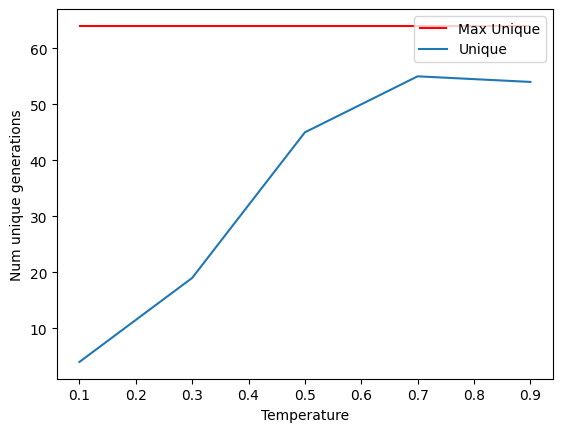

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

generation_config['do_sample'] = True

temperatures_range = np.arange(1, 10, 2) / 10
uniq_generations = []

for temperature in temperatures_range:
    generation_config['temperature'] = temperature
    output = model.generate(
        input_ids,
        attention_mask=attention_mask,
        **generation_config
    )
    decoded_generations = tokenizer.batch_decode(output)

    uniq_generations.append(len(set(decoded_generations)))

plt.ylabel("Num unique generations")
plt.xlabel("Temperature")
plt.hlines([ input_ids.shape[0] ], 0.1, 0.9, color='red', label='Max Unique')
plt.plot(temperatures_range, uniq_generations, label='Unique')
plt.legend()

### Temperature visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlabel('Token Index', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Effect of Temperature (0-10) on Sampling Distribution', fontsize=14, pad=20)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Original logits (model outputs before softmax)
logits = np.array([2.0, 1.5, 1.0, 0.5, 0.1])  # More varied distribution
token_labels = ['Token 1', 'Token 2', 'Token 3', 'Token 4', 'Token 5']

# Initialize bars with colors
colors = plt.cm.viridis(np.linspace(0, 1, len(logits)))
bars = ax.bar(token_labels, [0]*len(logits), color=colors)
texts = [ax.text(bar.get_x() + bar.get_width()/2, 0, '',
                ha='center', va='bottom', fontsize=10) for bar in bars]

# Temperature annotation with enhanced visibility
temp_text = ax.text(0.02, 0.95, 'Temperature: 0.00', transform=ax.transAxes,
                   ha='left', va='top', fontsize=14,
                   bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'))

# Add colorbar to show temperature scale
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=0, vmax=10))
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Temperature Scale', rotation=270, labelpad=15)

def apply_temperature(logits, temperature):
    """Apply temperature scaling to logits"""
    if temperature == 0:  # Handle zero temperature case
        temperature = 1e-10  # Very small value to avoid division by zero
    scaled_logits = logits / temperature
    return softmax(scaled_logits)

def update(frame):
    # Linear temperature range from 0 to 10
    temp = frame * 10 / 500  # frame goes from 0 to 100

    # Apply temperature
    probs = apply_temperature(logits, temp)

    # Update bars
    for bar, prob in zip(bars, probs):
        bar.set_height(prob)
        # Change color intensity based on temperature
        r, g, b, a = bar.get_facecolor()
        intensity = 0.5 + 0.5 * (temp / 10)  # Vary intensity with temperature
        bar.set_facecolor((r, g, b, intensity))

    # Update probability labels
    for text, bar in zip(texts, bars):
        text.set_text(f'{bar.get_height():.2f}')
        text.set_y(bar.get_height() + 0.02)
        text.set_color('black' if bar.get_height() < 0.7 else 'white')

    # Update temperature display
    temp_text.set_text(f'Temperature: {temp:.2f}')
    temp_text.set_color('red' if temp > 1 else 'blue')

    # Return all artists that need to be redrawn
    return list(bars) + texts + [temp_text]

# Create animation (100 frames for smooth transition)
ani = FuncAnimation(fig, update, frames=np.linspace(0, 100, 100),
                   blit=True, interval=200, repeat_delay=2000)

# For Jupyter notebook display
plt.close()
HTML(ani.to_html5_video())

# To save the animation (uncomment if needed)
# ani.save('temperature_effect_0_to_10.mp4', writer='ffmpeg',

### Count correct threads

In [ ]:
generation_config = {
    "do_sample": True,
    "temperature": 0.9,
    "top_p": 1.0,
    "top_k": None,
    "min_p": None,
    "repetition_penalty": 1.0,
    "max_new_tokens": 500,
}

output = model.generate(
    input_ids,
    attention_mask=attention_mask,
    **generation_config
)

decoded_generations = tokenizer.batch_decode(output)

In [ ]:
correct_answer = '3, \\frac{\pi}{2}'

print("Count correct answers", sum( correct_answer in x for x in decoded_generations ))

Count correct answers 4


In [ ]:
partially_correct = '\\frac{\pi}{2}'

print("Count partially correct answers", sum( partially_correct in x for x in decoded_generations ))

Count partially correct answers 15


In [ ]:
print(decoded_generations[1])


Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$
To convert the point $(0, 3)$ from rectangular coordinates to polar coordinates, we use the formula:

\[ r = \sqrt{x^2 + y^2} \]
\[ \theta = \arctan \left( \frac{y}{x} \right) \]

Plugging in the values, we get:

\[ r = \sqrt{0^2 + 3^2} = \sqrt{9} = 3 \]
\[ \theta = \arctan \left( \frac{3}{0} \right) \]
\[ \theta = -\frac{\pi}{2} \]

However, given that $r > 0$ and $0 \le \theta < 2\pi$, the value of $\theta$ becomes undefined because the negative result is not in the specified interval. Therefore, we consider the additional restriction that $\theta$ is between 0 and $\pi$. In this case, $\theta = -\frac{\pi}{2}$ is valid since it was introduced to ensure the result is in the correct interval, with $\theta = \pi$ not being valid because it exceeds the range $0 \le \theta < 2\pi$.

Thus, the point $(0, 3)$ in polar coordinates

### На каких задачах хороши ризонеры?

- Для сложных задач, в которых скорость не критична, но точность ответа важна

----

## Efficiency

### `dtype=torch.bfloat16`

### Batch Size

### Torch Compile

### PEFT

### The asynchronous nature of CUDA

---

## Дополнительные материалы

### Evaluation
- [Inside vLLM: Anatomy of a High-Throughput LLM Inference System](https://www.aleksagordic.com/blog/vllm)
- [Человек и LLM. Как оценивать качество моделей и строить метрики](https://habr.com/ru/companies/yandex/articles/861084/)


### Test Time Scaling

- [🤗 huggingface/trl](https://github.com/huggingface/trl) HF transformers reinforcement learning
- [GRPO Qwen0.5 Huggingface Example](https://huggingface.co/docs/trl/main/grpo_trainer) — наглядный пример работы GRPO на маленькой модельке и игрушечной задачке
- [The State of Reinforcement Learning for LLM Reasoning](https://magazine.sebastianraschka.com/p/the-state-of-llm-reasoning-model-training) (Sebastian Raschka, 2025) — свежий пост, но база
- [Mini-R1: Reproduce Deepseek R1 „aha moment" a RL tutorial](https://www.philschmid.de/mini-deepseek-r1) — нужно 4 H100 и за 6 часов вы воспроизвели «aha moment» на настоящем, не игрушечном бенчмарке по математическим навыкам модельки
- [Speculations on Test-Time Scaling | Richard M. Karp Distinguished Lecture](https://www.youtube.com/watch?v=6fJjojpwv1I) — Sasha Rush (Associate Professor @ Cornell University, Researcher @ HuggingFace 🤗) — сюда за интуицией
- [Scaling test time compute with open models](https://huggingface.co/spaces/HuggingFaceH4/blogpost-scaling-test-time-compute) — Блог HF. Пример test time scaling, очень интересный, но немножко тупиковый (см. последнюю часть — «Where to go from here?»). [**Разбор в Сиолошной**](https://t.me/seeallochnaya/2136)
- [DPO в GigaChat](https://habr.com/ru/companies/sberdevices/articles/890552/) — как заводили DPO в GigaChat (спойлер: завелся, но не просто)
- [PPO и DPO в YandexGPT](https://habr.com/ru/companies/yandex/articles/817391/) — как заводили PPO и DPO в YandexGPT
- [**DeepSeek-R1 для чайников**](https://habr.com/ru/companies/airi/articles/879178/) — разбор GRPO на Хабре от Антона Разжигаева

**Работает ли RL в LLM Alignment**

- [Reasoning models do not always say what they think](https://www.anthropic.com/research/reasoning-models-dont-say-think) — (anthropic, 2025) — [Статья](https://assets.anthropic.com/m/71876fabef0f0ed4/original/reasoning_models_paper.pdf), [**Разбор в «Гречневые мысли»**](https://t.me/buckwheat_thoughts/181). А что если все, что генерят ризонеры во время процесса мышления, — это просто побочный продукт? Может быть, на буст в качестве влияет большее количество сгенеренных токенов в контексте и интерпретация задачи на промежуточных слоях трансформера, но не то, что на самом деле генерируется при декодировании?
- [Does Reinforcement Learning Really Incentivize Reasoning Capacity in LLMs Beyond the Base Model?](https://www.arxiv.org/abs/2504.13837) [**Разбор AbstractDL**](https://t.me/abstractDL/332)

